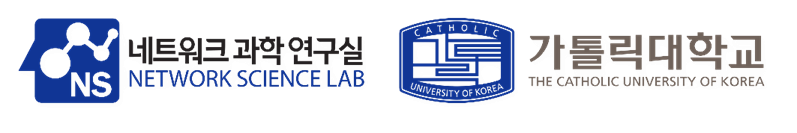

# 🌐 Graph Visualization Tutorial: NetworkX vs iPySigma


This notebook loads `dataset_2.json`, builds a directed graph, visualizes it with both **NetworkX** and **iPySigma**, and compares their strengths.


## 🎯 Learning goals

- 📥 Load graph data from JSON

- 🧱 Build a directed graph with node attributes

- 🖼️ Visualize with NetworkX (static)

- 🕹️ Visualize with iPySigma (interactive)

- 💾 Export an interactive graph to HTML


## 1. Setup 🧰

Import the required libraries for data loading and graph visualization.


In [1]:
import json
import time
import matplotlib.pyplot as plt
import networkx as nx
from ipysigma import Sigma


## 2. Load and inspect data 📂

Read the JSON file, then quickly inspect keys, sample edge, and sample node.


In [2]:
DATA_PATH = "./data/dataset_2.json"

with open(DATA_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

print(f"Loaded: {len(data['nodes'])} nodes, {len(data['edges'])} edges")


Loaded: 2085 nodes, 5409 edges


In [3]:
print("Top-level keys:", list(data.keys()))

Top-level keys: ['nodes', 'edges', 'clusters', 'tags']


In [4]:
print("Example edge:", data["edges"][0])

Example edge: ['cytoscape', 'computational genomics']


In [5]:
sample_edge = tuple(data["edges"][0])
print("Same edge as tuple:", sample_edge)


Same edge as tuple: ('cytoscape', 'computational genomics')


In [6]:
print("Example node record:")
data["nodes"][0]

Example node record:


{'key': 'cytoscape',
 'label': 'Cytoscape',
 'tag': 'Tool',
 'URL': 'https://en.wikipedia.org/wiki/Cytoscape',
 'cluster': '0',
 'x': 643.82275390625,
 'y': -770.3126220703125,
 'score': 6.909602204225056e-05}

## 3. Build the directed graph 🧭

Create the graph, add nodes/edges, and attach node attributes.


In [7]:
# 1) Create a directed graph

DG = nx.DiGraph()


In [8]:
# 2) Add all nodes and edges

node_ids = [node["key"] for node in data["nodes"]]
edge_tuples = [tuple(edge) for edge in data["edges"]]

DG.add_nodes_from(node_ids)
DG.add_edges_from(edge_tuples)

print("Graph built successfully.")


Graph built successfully.


In [9]:
print("Number of edges:", DG.number_of_edges())

Number of edges: 5409


In [10]:
print("Number of nodes:", DG.number_of_nodes())

Number of nodes: 2085


In [13]:
# 3) Build node attribute dictionary

keys_to_extract = ["label", "tag", "URL"]

attrs_dict = {}

for node_attrs in data["nodes"]:
    node_id = node_attrs["key"]
    attrs_dict[node_id] = {
        key: node_attrs[key]
        for key in keys_to_extract if key in node_attrs
    }

In [14]:
print("Sample node attributes:")
list(attrs_dict.items())[:3]


Sample node attributes:


[('cytoscape',
  {'label': 'Cytoscape',
   'tag': 'Tool',
   'URL': 'https://en.wikipedia.org/wiki/Cytoscape'}),
 ('microsoft excel',
  {'label': 'Microsoft Excel',
   'tag': 'Tool',
   'URL': 'https://en.wikipedia.org/wiki/Microsoft%20Excel'}),
 ('gephi',
  {'label': 'Gephi',
   'tag': 'Tool',
   'URL': 'https://en.wikipedia.org/wiki/Gephi'})]

In [15]:
# 4) Attach attributes to graph nodes

nx.set_node_attributes(DG, attrs_dict)
print("Attributes attached.")


Attributes attached.


## 4. Static visualization with NetworkX 🖼️

This view is quick and useful for simple, static snapshots.


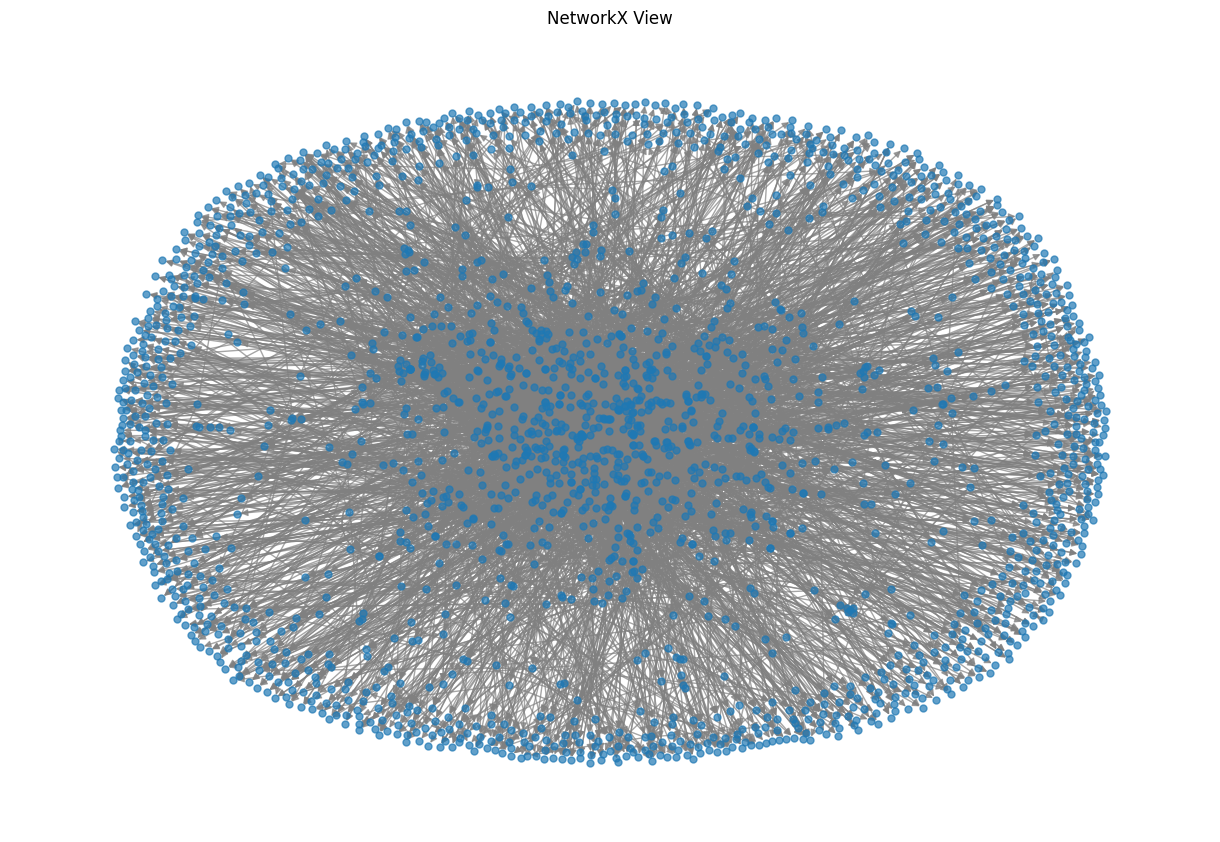

NetworkX draw time: 22.8404 s


In [16]:
# NetworkX visualization 

start_time = time.time()

plt.figure(figsize=(12, 8))

pos = nx.spring_layout(DG, seed=42)

nx.draw(
    DG,
    pos=pos,
    with_labels=False,
    node_size=25,
    edge_color="gray",
    alpha=0.7,
)
plt.title("NetworkX View")
plt.show()

end_time = time.time()

print(f"NetworkX draw time: {end_time - start_time:.4f} s")


## 5. Interactive visualization with iPySigma 🕹️

Use interactive controls to explore structure, clusters, and node properties.


In [17]:
# iPySigma visualization 

start_time = time.time()

Sigma(
    DG,
    node_color="tag",
    node_label_size=DG.degree,
    node_size=DG.degree,
    default_edge_type="curve",
)

end_time = time.time()

print(f"iPySigma render setup time: {end_time - start_time:.4f} s")


iPySigma render setup time: 0.0334 s


In [ ]:
# iPySigma with Louvain communities

Sigma(
    DG,
    node_metrics=["louvain"],
    node_color="louvain",
    node_size=DG.degree,
    node_size_range=(3, 20),
    max_categorical_colors=30,
    default_edge_type="curve",
    node_border_color_from="node",
    default_node_label_size=14,
)


Sigma(nx.DiGraph with 2,085 nodes and 5,409 edges)

## 6. Export interactive HTML 💾

Save the iPySigma result to an HTML file so it can be shared outside the notebook.


In [18]:
Sigma.write_html(
    DG,
    './output_ipysigma.html',
    fullscreen=True,
    node_metrics=['louvain'],
    node_color='louvain',
    node_size_range=(3, 20),
    max_categorical_colors=30,
    default_edge_type='curve',
    node_border_color_from='node',
    default_node_label_size=14,
    node_size=DG.degree
)

| Expected output:
    
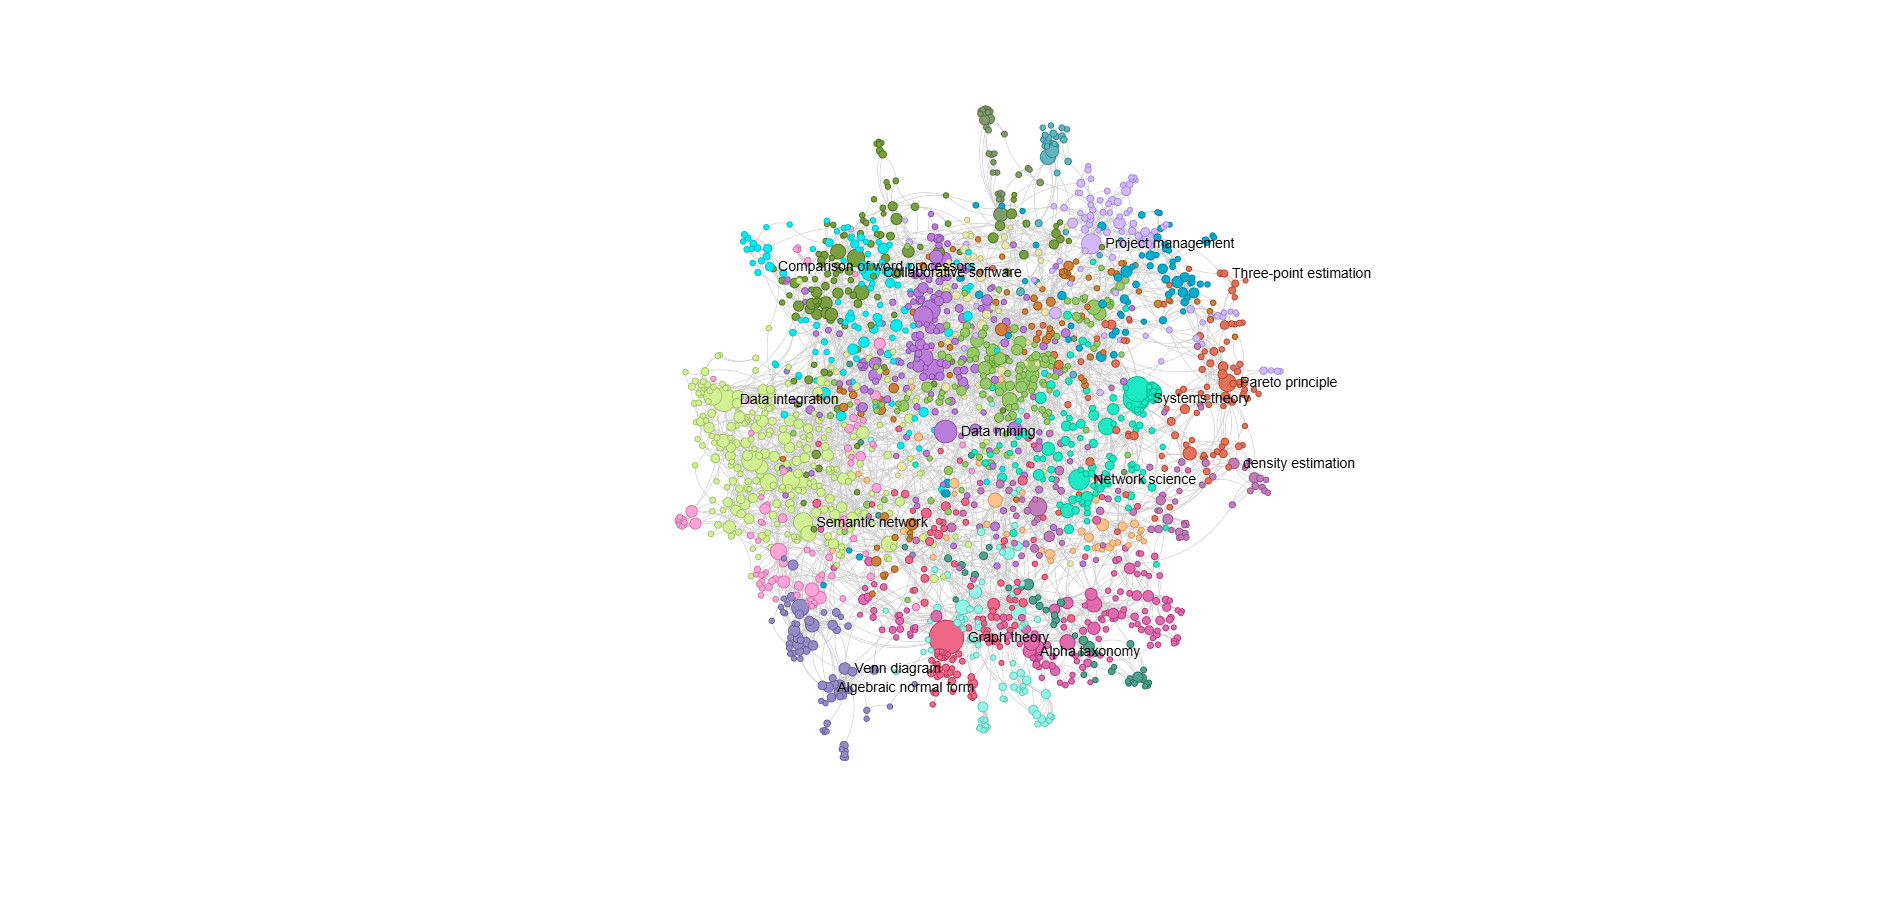

> References: https://github.com/msbased/medium_ipysigma